In [ ]:
import os
import sys

# to setup import paths add project root dirs to sys.path
sys.path.append(os.path.join(os.getcwd(), "..", ".."))
from baseVR.base_functionality import init_import_paths
init_import_paths()

In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# %matplotlib qt
%matplotlib widget

from analytics_processing import analytics
import analytics_processing.analytics_constants as C
from CustomLogger import CustomLogger as Logger

from dashsrc.plot_components.plot_wrappers.data_selection import group_filter_data

from analytics_processing.modality_loading import session_modality_from_nas
from analytics_processing.sessions_from_nas_parsing import sessionlist_fullfnames_from_args
from analytics_processing.sessions_from_nas_parsing import fullfnames2snames

# import GridSpecFromSubplotSpec
from matplotlib.gridspec import GridSpecFromSubplotSpec
import scipy.stats as stats
import statsmodels.api as sm
from matplotlib.colors import LinearSegmentedColormap, Normalize



In [ ]:
output_dir = "./outputs/experimental/"
data = {}
nas_dir = C.device_paths()[0]
Logger().init_logger(None, None, logging_level="DEBUG")

In [ ]:
animal_ids = [6]
paradigm_ids = [1100]
session_ids = None

In [ ]:
session_dirs, _ = sessionlist_fullfnames_from_args(paradigm_ids, animal_ids, session_ids)
session_names = fullfnames2snames(session_dirs)

In [ ]:


fr_raw = analytics.get_analytics('FiringRate40msHz', session_names=session_names)
fr = fr_raw.drop("from_ephys_timestamp", axis=1)
fr.index = fr.index.droplevel((0,1,3, ))
fr.set_index('to_ephys_timestamp', append=True, inplace=True)
fr['global_t'] = np.arange(40_000, 40_000*len(fr)+1, 40_000)
fr.set_index('global_t', append=True, inplace=True)
fr.index = fr.index.rename(['session_id', 'session_t', 'global_t'])
fr

In [ ]:
# columns = [
#             'frame_velocity', #'abs_frame_raw_quantile',
#             'abs_frame_raw', 
            
#             'frame_acceleration', 
#             'frame_decceleration',
#             'abs_frame_acceleration', 
            
#             'frame_yaw', 
#             'frame_yaw_left',
#             'frame_yaw_right', 
            
#             'frame_pitch', 
#             'abs_frame_yaw', 
#             'abs_frame_pitch',
#             'frame_pitch_left', 
#             'frame_pitch_right', 
            
#             'lick_count',
#             'post_reward_sound', 
#             'post_reward', 
            
#             'frame_position',
#             'zone_before_reward1', 
#             'zone_before_reward2', 
#             'zone_between_cues',
#             'zone_cue2', 
#             'zone_cue2_passed', 
#             'zone_cue2_visible',
#             'zone_post_reward', 
#             'zone_reward1', 
#             'zone_reward2', 
#             'head_angle',
#             'head_angle_left', 'head_angle_right', 'head_angle_velocity',
#             'head_angle_velocity_left', 'head_angle_velocity_right']
        
behavior_glm_input = analytics.get_analytics('Behavior40msAligned', session_names=session_names)
# drop index level
behavior_glm_input.index = behavior_glm_input.index.droplevel(['entry_id', 'paradigm_id', 'animal_id'])
drop_cols = ['trial_id',
             'cue',
             'trial_outcome',
             'choice_R1',
             'choice_R2',
             'trial_start_pc_timestamp',
             'from_ephys_timestamp',
             'to_ephys_timestamp',]
behavior_glm_input.drop(drop_cols, axis=1, inplace=True)
behavior_glm_input

In [ ]:
plt.close("all")
for col in behavior_glm_input.columns:
    plt.figure()
    behavior_glm_input[col].hist(bins=100)
    plt.title(col)
    plt.show()

frame_velocity
frame_raw
frame_raw_quantile
frame_acceleration
abs_frame_acceleration
frame_positive_acceleration
frame_negative_acceleration
frame_yaw
frame_yaw_left
frame_yaw_right
frame_pitch
frame_pitch_left
frame_pitch_right
lick_count
post_lick
post_reward_sound
post_reward
frame_position
zone_before_reward1
zone_before_reward2
zone_between_cues
zone_cue2
zone_cue2_passed
zone_cue2_visible
zone_post_reward
zone_reward1
zone_reward2
head_angle
head_angle_left
head_angle_right
head_angle_velocity
head_angle_velocity_left
head_angle_velocity_right
Drawing regresser: frame_velocity ... 
Drawing regresser: frame_raw ... 
Drawing regresser: frame_raw_quantile ... 
Drawing regresser: frame_acceleration ... 
Drawing regresser: abs_frame_acceleration ... 
Drawing regresser: frame_positive_acceleration ... 
Drawing regresser: frame_negative_acceleration ... 
Drawing regresser: frame_yaw ... 
Drawing regresser: frame_yaw_left ... 
Drawing regresser: frame_yaw_right ... 
Drawing regresser: f

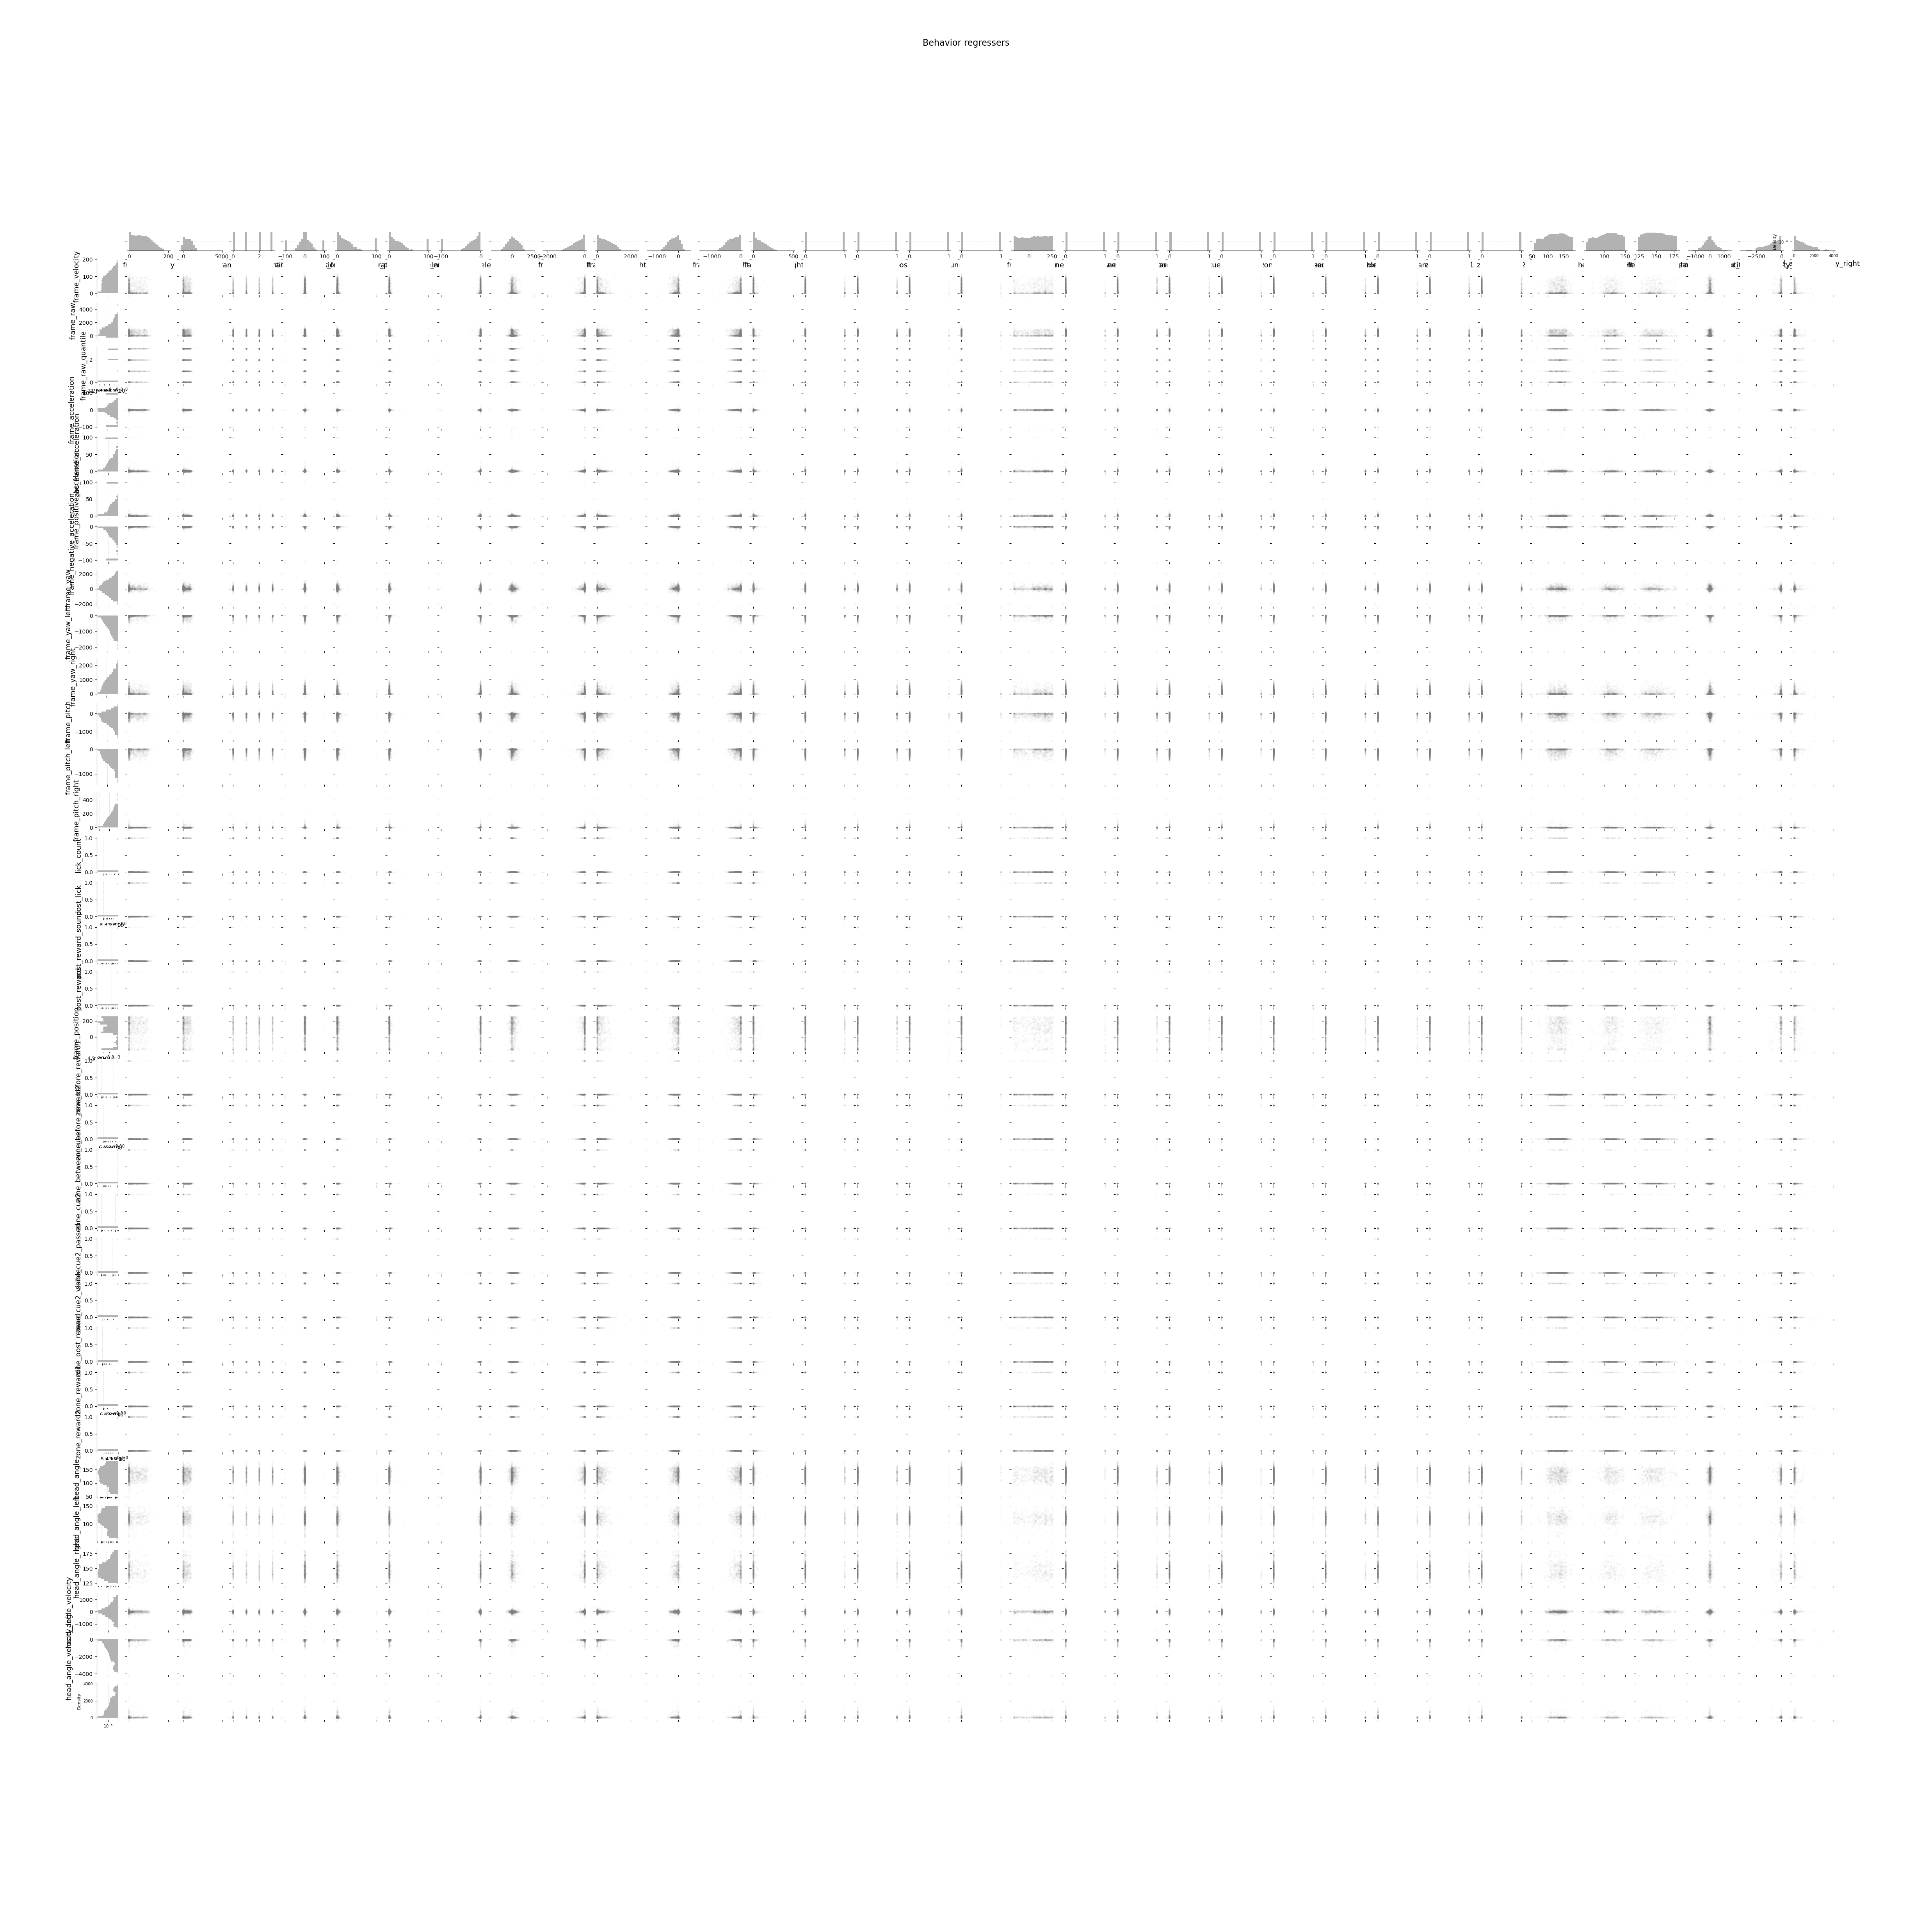

In [ ]:
def add_joint_plot(fig, parent_spec, x, y, color='gray', alpha=0.01, share_x_with=None, share_y_with=None):
    """Creates a joint scatter plot (no marginals) inside a subplot grid cell."""
    # Convert to numpy arrays
    x_np = np.array(x, dtype=np.float64) # behavior variable, regresser
    y_np = np.array(y, dtype=np.float64) # firing rate
    
    # Create mask for valid values
    valid_mask = ~(np.isnan(x_np) | np.isnan(y_np))
    x_clean = x_np[valid_mask]
    y_clean = y_np[valid_mask]

    # Create subplot and share axes if requested
    gs = GridSpecFromSubplotSpec(1, 1, subplot_spec=parent_spec)
    ax_joint = fig.add_subplot(gs[0, 0], sharex=share_x_with, sharey=share_y_with)

    # Plot data, y the firing rate is on the x axis, x the behavior regresser is on the y axis
    # add jitter to x for better visualization
    # jitter_strength = 0.1 * (np.max(y_clean) - np.min(y_clean))
    # y_jittered = y_clean + np.random.uniform(-jitter_strength, jitter_strength, size=y_clean.shape)
    y_jittered = y_clean
    ax_joint.scatter(y_jittered, x_clean, s=6, color=color, alpha=alpha)
    
    # jitter the other
    # jitter_strength = 0.05 * (np.max(x_clean) - np.min(x_clean))
    # x_jittered = x_clean + np.random.uniform(-jitter_strength, jitter_strength, size=x_clean.shape)
    x_jittered = x_clean
    ax_joint.scatter(y_jittered, x_jittered, s=6, color=color, alpha=alpha)

    # Turn off ticks
    ax_joint.tick_params(labelleft=False, labelbottom=False)
    [ax_joint.spines[side].set_visible(False) for side in ['top', 'right', 'left', 'bottom']]
    
    return ax_joint

# ==============================================================
# === GLM FITTING AND VISUALIZATION ============================
# ==============================================================

def plot_neuron_session_histograms(behavior_aligned, ):
    session_names = [f"S{s_id:02}" for s_id in behavior_aligned.index.unique('session_id')]
    n_sessions = len(session_names)
    n_regressers = behavior_aligned.shape[1]

    # Create figure with specific layout
    fig = plt.figure(figsize=(1.5 * n_regressers, 1.5 * n_regressers))
    
    # Create GridSpec with extra row/column for histograms
    outer_gs = plt.GridSpec(
        nrows=n_regressers + 1, 
        ncols=n_regressers + 1, 
        figure=fig,
        wspace=0.2, hspace=0.2,
        width_ratios=[0.5] + [1]*n_regressers,  # Make first column narrower
        height_ratios=[0.5] + [1]*n_regressers  # Make first row shorter
    )

    # === LEFT COLUMN: behavior histograms ===
    left_hist_axes = []
    for row, regr_name in enumerate(behavior_aligned.columns):
        print(regr_name)
        ax = fig.add_subplot(outer_gs[row + 1, 0])
        left_hist_axes.append(ax)
        regr_data = behavior_aligned[regr_name]
        
        # Calculate density for consistent y-limits across row
        counts, bins, _ = ax.hist(regr_data, bins=20, density=True, 
                                orientation="horizontal", color='gray', alpha=0.6)
        
        ax.set_ylabel(f"{regr_name}", fontsize=13)
        ax.set_xscale('log')
        ax.grid(axis='x', linestyle='--', alpha=0.4)
        [ax.spines[side].set_visible(False) for side in ['top', 'bottom', 'right']]
        
        # Store density limits for sharing
        ax.density_limits = (min(counts[counts > 0]), max(counts))
        
        if row == n_regressers - 1:
            ax.tick_params(labelsize=7, labelbottom=True)
            ax.set_ylabel("Density", fontsize=6)
        else:
            plt.setp(ax.get_xticklabels(), visible=False)
            
        # Reverse x-axis for better visualization
        xlim = ax.get_xlim()
        ax.set_xlim(xlim[1], xlim[0])

    # === TOP ROW: behavior again ===
    # === TOP ROW: behavior histograms ===
    top_row_axes = []
    shared_ylim = None
    
    for col, regr_name in enumerate(behavior_aligned.columns):
        ax = fig.add_subplot(outer_gs[0, col + 1])
        top_row_axes.append(ax)
        regr_data = behavior_aligned[regr_name]
        
        # Calculate density with same bins as left column
        counts, bins, _ = ax.hist(regr_data, bins=20, density=True, 
                                orientation="vertical", color='gray', alpha=0.6)
        
        ax.set_xlabel(f"{regr_name}", fontsize=13)
        ax.set_yscale('log')
        ax.grid(axis='y', linestyle='--', alpha=0.4)
        [ax.spines[side].set_visible(False) for side in ['top', 'right', 'left']]
        
        # Share y limits across all top histograms
        if shared_ylim is None:
            shared_ylim = (min(counts[counts > 0]), max(counts))
        ax.set_ylim(shared_ylim)
        ax.set_title(f"{regr_name}", fontsize=10)
        
        # Only show x ticks for rightmost histogram
        if col == n_regressers - 1:
            ax.tick_params(labelsize=7, labelleft=True)
            ax.set_ylabel("Density", fontsize=6)
        else:
            plt.setp(ax.get_yticklabels(), visible=False)
    
    # === MAIN GRID: joint plots ===
    # get min and max of behavior_aligned for normalization
    
    for row, regr_name in enumerate(behavior_aligned.columns):
        print("Drawing regresser:", regr_name, '... ')
        regr_data = behavior_aligned[regr_name].values
        if len(regr_data) > 1_000:
                regr_data = np.random.choice(regr_data, size=1_000, replace=False)
        for col, regr_name_2 in enumerate(behavior_aligned.columns):
            regr_data_2 = behavior_aligned[regr_name_2].values
            if len(regr_data_2) > 1_000:
                regr_data_2 = np.random.choice(regr_data_2, size=1_000, replace=False)
            
            _ = add_joint_plot(fig, outer_gs[row + 1, col + 1], 
                               regr_data, regr_data_2,
                               share_x_with=top_row_axes[col],
                               share_y_with=left_hist_axes[row])
            # break
        # break
    fig.suptitle(f"Behavior regressers", fontsize=16)
        
    # set left and right margin to 0.05
    plt.subplots_adjust(left=0.05, right=0.95)
    # plt.savefig(f"../outputs/glm_results/neuron_{neuron_i}_GLM.png", dpi=300)
    plt.show()
    # plt.close()

plt.close("all")
plot_neuron_session_histograms(behavior_glm_input)